In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

FUNDAMENTOS DEL APRENDIZAJE NO SUPERVISADO

El modelo de aprendizaje no supervisado ocurre cuando el modelo encuentra patrones solo, no hay variable objetivo (no hay “y”)

Casos reales de aplicación:
- Clusterización → agrupar clientes
- Reducción dimensional → simplificar datos
- Reglas de asociación → patrones tipo “compran juntos”

RESUMEN COMPARATIVO 

| Supervisado     | No supervisado     |
| --------------- | ------------------ |
| Tiene etiquetas | No tiene etiquetas |
| Predice         | Descubre patrones  |

CLUSTERIZACIÓN

Casos reales de aplicación
- Segmentar clientes: Identificar grupos con comportamientos de compra similares.
- Detectar fraude: Encontrar patrones inusuales o aislados.
- Agrupar productos: Categorización automática por atributos.

Algoritmos Principales

| Algoritmo | Funcionamiento | ✔️ Ventajas | ❌ Desventajas |
| :--- | :--- | :--- | :--- |
| **K-Means** | Crea clusters esféricos basados en centroides. | Simple, rápido y eficiente en grandes datasets. | Requiere definir **K** y es sensible a *outliers*. |
| **DBSCAN** | Agrupa puntos por densidad (vecindad). | Detecta ruido (outliers) y formas complejas. | Difícil ajustar parámetros (`eps` y `min_samples`). |
| **Jerárquico** | Construye un árbol (dendrograma). | No necesita un **K** inicial y es muy visual. | Muy costoso computacionalmente 

PROBLEMA: SE TIENE DATASET DEL DEPARTAMENTO DE INTELIGENCIA DE NEGOCIOS DE LA EMPRESA "REAIL INSIGHTS", SE NECESITA ENCONTRAR UN MODELO QUE LOGRE ENCONTRAR GRUPO DE CLIENTES CON PATRONES DE COMPRA (SEGMENTACIÓN).

In [122]:
# Leer un archivo Excel
df = pd.read_excel("dataset.xlsx")

# Mostrar las primeras filas
df.head()

,ID,Gender,Married,Age,Profession,Work_Experience,Spending_Score,Family_Size
0,458989,Female,Yes,36,Engineer,0.0,Low,1.0
1,458994,Male,Yes,37,Healthcare,8.0,Average,4.0
2,458996,Female,Yes,69,NaN,0.0,Low,1.0
3,459000,Male,Yes,59,Executive,11.0,High,2.0
4,459001,Female,No,19,Executive,NaN,Low,4.0


Diccionario de variables
| Variable          | Significado              |
| ----------------- | ------------------------ |
| Gender            | Género                   |
|Married            | ¿Está casado   (Sí o No)?|
| Age               | Edad                     |
| Profession        | Profesión                |
| Work_Experience   | Años experiencia laboral |
| Spending_Score    | Puntaje de gasto         |
| Family_Size       | Tamaño de la familia     |

In [123]:
df['Profession'].value_counts()

Profession
Entertainment    802
Executive        588
Healthcare       418
Doctor           242
Engineer         236
Lawyer           221
Homemaker         82
Name: count, dtype: int64

In [124]:
df['Spending_Score'].value_counts()

Spending_Score
Low        1616
Average     625
High        386
Name: count, dtype: int64

In [125]:
#Limpieza y preprocesamiento
#Se eliminan variables innecesarias
df = df.drop(["ID"], axis=1)

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2627 entries, 0 to 2626
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           2627 non-null   object 
 1   Married          2577 non-null   object 
 2   Age              2627 non-null   int64  
 3   Profession       2589 non-null   object 
 4   Work_Experience  2358 non-null   float64
 5   Spending_Score   2627 non-null   object 
 6   Family_Size      2514 non-null   float64
dtypes: float64(2), int64(1), object(4)
memory usage: 143.8+ KB


In [127]:
#Reemplazo de valores faltantes
# Numéricas
df['Work_Experience'] = df['Work_Experience'].fillna(df['Work_Experience'].median())

# Categóricas
df['Profession'] = df['Profession'].fillna("Desconocido")

In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2627 entries, 0 to 2626
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           2627 non-null   object 
 1   Married          2577 non-null   object 
 2   Age              2627 non-null   int64  
 3   Profession       2627 non-null   object 
 4   Work_Experience  2627 non-null   float64
 5   Spending_Score   2627 non-null   object 
 6   Family_Size      2514 non-null   float64
dtypes: float64(2), int64(1), object(4)
memory usage: 143.8+ KB


In [129]:
#- Los valores faltantes fueron tratados mediante imputación. 
df = df.dropna()

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2466 entries, 0 to 2626
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           2466 non-null   object 
 1   Married          2466 non-null   object 
 2   Age              2466 non-null   int64  
 3   Profession       2466 non-null   object 
 4   Work_Experience  2466 non-null   float64
 5   Spending_Score   2466 non-null   object 
 6   Family_Size      2466 non-null   float64
dtypes: float64(2), int64(1), object(4)
memory usage: 154.1+ KB


- Para variables numéricas se utilizó la mediana, mientras que para variables categóricas se asignó la categoría "Desconocido" , los demás valores nulos se eliminaron pero sólo fueron 161 registros (6% aprox.) de 2627 registros en total"

In [131]:
df.head()

,Gender,Married,Age,Profession,Work_Experience,Spending_Score,Family_Size
0,Female,Yes,36,Engineer,0.0,Low,1.0
1,Male,Yes,37,Healthcare,8.0,Average,4.0
2,Female,Yes,69,Desconocido,0.0,Low,1.0
3,Male,Yes,59,Executive,11.0,High,2.0
4,Female,No,19,Executive,1.0,Low,4.0


*Convertir variables categóricas a numéricas*

In [132]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,Age,Work_Experience,Family_Size,Gender_Male,Married_Yes,Profession_Doctor,Profession_Engineer,Profession_Entertainment,Profession_Executive,Profession_Healthcare,Profession_Homemaker,Profession_Lawyer,Spending_Score_High,Spending_Score_Low
0,36,0.0,1.0,False,True,False,True,False,False,False,False,False,False,True
1,37,8.0,4.0,True,True,False,False,False,False,True,False,False,False,False
2,69,0.0,1.0,False,True,False,False,False,False,False,False,False,False,True
3,59,11.0,2.0,True,True,False,False,False,True,False,False,False,True,False
4,19,1.0,4.0,False,False,False,False,False,True,False,False,False,False,True


Las variables categóricas fueron transformadas mediante One-Hot Encoding para permitir su uso en algoritmos de machine learning, los cuales requieren datos numéricos.

*ESCALAR DATOS*

In [133]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

PARA RECORDAR: 
- Los algoritmos (KMEANS /DBSCAN / Jerárquico) crean clusters
- PCA o t-SNE solo sirven para graficar

- Para elegir el **K** ideal en K-Means, se debe utilizar el **Método del Codo (Elbow Method)** o el **Coeficiente de Silueta**.

MÉTODO DEL CODO

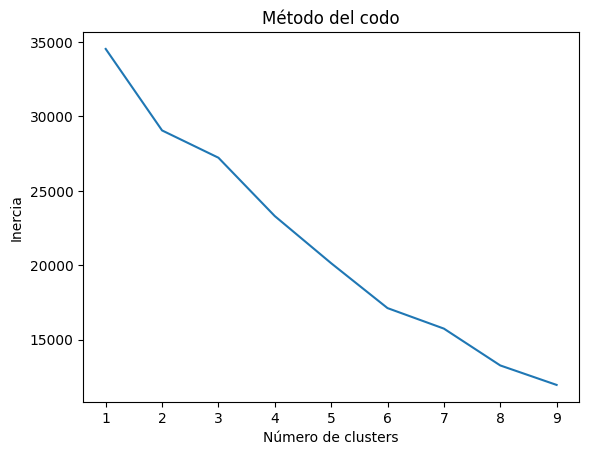

In [134]:
inercia = []

for k in range(1,10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inercia.append(km.inertia_)

plt.plot(range(1,10), inercia)
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.savefig("Método del codo.png", dpi=300, bbox_inches="tight")
plt.show()

Aplicar K-Means

In [135]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters_k = kmeans.fit_predict(X_scaled)
df['cluster'] = clusters_k

COEFICIENTE DE SILUETA

In [136]:
silhouette_score(X_scaled, clusters_k)

0.22565333475891675

In [137]:
df.groupby('cluster').mean()

,Age,Work_Experience,Family_Size,Gender_Male,Married_Yes,Profession_Doctor,Profession_Engineer,Profession_Entertainment,Profession_Executive,Profession_Healthcare,Profession_Homemaker,Profession_Lawyer,Spending_Score_High,Spending_Score_Low
cluster,,,,,,,,,,,,,,
0,38.614035,2.385965,2.916667,0.539474,0.526316,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.043860,0.657895
1,31.672096,3.023887,2.969598,0.485342,0.048860,0.0,0.096634,0.263844,0.186754,0.394137,0.044517,0.001086,0.000000,0.996743
2,48.657633,2.108401,2.847335,0.611563,1.000000,0.0,0.116531,0.476965,0.340560,0.018067,0.027100,0.000000,0.222222,0.308040
3,75.680952,1.190476,2.004762,0.490476,0.938095,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.538095,0.433333


🟢 Cluster 0: Profesionales de bajo consumo|Edad media: ~39 años |Profesión dominante: Doctor (100%)|Gasto: mayormente bajo (65%)|Estado civil: dividido

- Perfil: Clientes profesionales, relativamente jóvenes, pero con bajo nivel de gasto.
- Insight: Aunque tienen perfil profesional, no están generando alto valor comercial.
- Acciones: Promociones personalizadas, Incentivos de consumo,Programas de fidelización

🔴 Cluster 1: Clientes jóvenes de bajo consumo|Edad media: ~32 años|Profesiones variadas (Engineer, Entertainment, Executive, Healthcare, Homemaker,Lawyer)| Gasto: principalmente bajo (99%)|Menor tasa de matrimonio

- Perfil: Clientes activos pero con bajo compromiso de compra.
- Insight: Segmento con potencial, pero poco explotado.
- Acciones: Marketing digital|Promociones agresivas|Programas de activación

🔵 Cluster 2: Adultos casados con gasto medio/alto|Edad media: ~49 años|Estado civil dominante: Casados (100%)|Profesiones dominantes (Entertainment, Executive) |Gasto: mixto (alto(22%) y bajo(30%))

- Perfil: Clientes adultos, con comportamiento equilibrado.
- Insight: Clientes consistentes → buen target para fidelización
- Acciones: Programas de fidelización|Ofertas personalizadas

🟡 Cluster 3: Adultos mayores de alto valor|Edad media: ~75 años|Profesión dominante: Lawyer (100%)|Gasto: principalmente alto (54%)|Alta proporción casados

- Perfil: Clientes consolidados, probablemente retirados o con patrimonio acumulado y alto poder adquisitivo.
- Insight: Segmento premium especializado
- Acciones: Programas VIP|Beneficios exclusivos|Atención personalizada

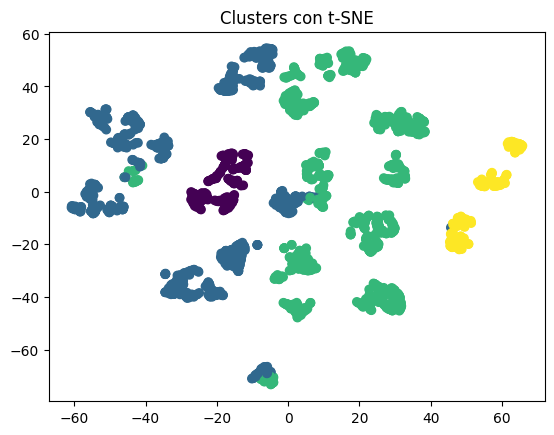

In [138]:
#Se aplica TSNE para ver si relamente hay grupos en los datos
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=clusters_k, cmap='viridis')
plt.title("Clusters con t-SNE")
plt.savefig("Clusters con t-SNE.png", dpi=300, bbox_inches="tight")
plt.show()

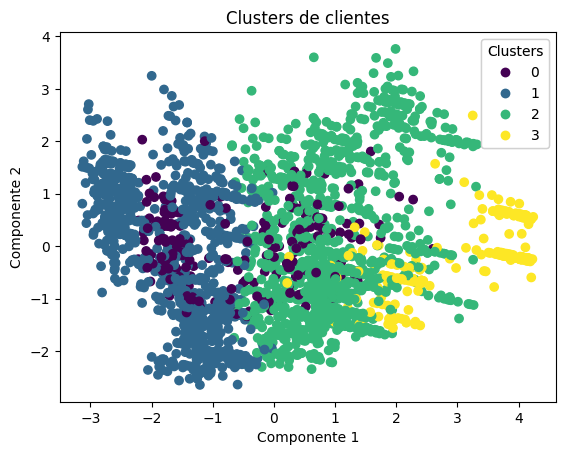

In [139]:
#Se aplica PCA para ver los grupos con 2 componentes principales
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_k, cmap='viridis')

plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.title("Clusters de clientes")

# Crear leyenda 
legend = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend)

plt.show()

Se aplicaron técnicas de reducción dimensional como PCA y t-SNE para visualizar los clusters. Mientras PCA permitió observar la estructura general de los datos, t-SNE evidenció una mejor separación local entre los grupos, facilitando la identificación de patrones más definidos.

La segmentación permitió identificar cuatro grupos diferenciados de clientes con características demográficas y de comportamiento distintas. Destacan los segmentos de alto valor asociados a perfiles profesionales específicos, así como grupos de bajo consumo con potencial de crecimiento. Estos hallazgos permiten diseñar estrategias comerciales más efectivas y focalizadas.

DBSCAN

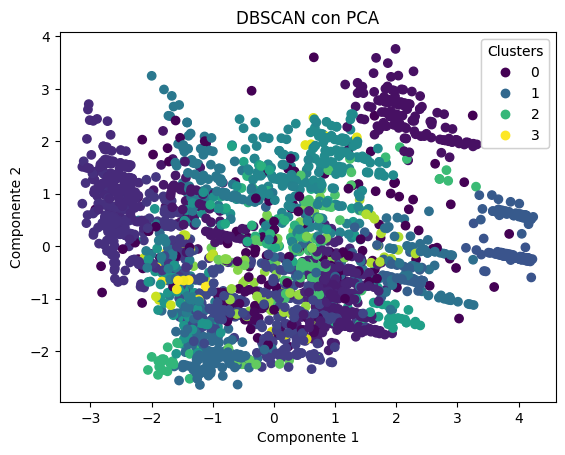

In [140]:
db = DBSCAN(eps=1.5, min_samples=5)
clusters_db = db.fit_predict(X_scaled)
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_db, cmap='viridis')
plt.title("DBSCAN con PCA")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")

legend = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend)

plt.show()

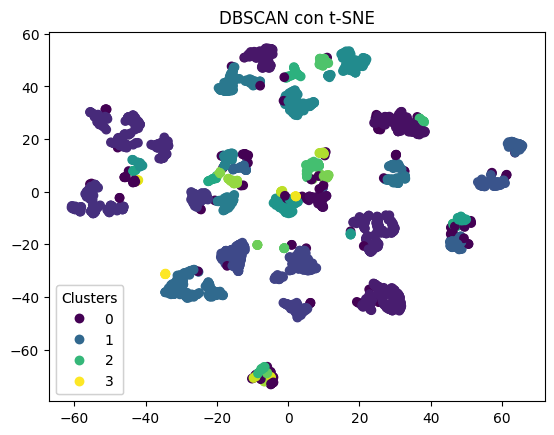

In [141]:
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=clusters_db, cmap='viridis')
plt.title("DBSCAN con t-SNE")

legend = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend)

plt.show()

¿Ruido en DBSCAN?: Presencia de -1, quiere decir que hay outliers.

In [142]:
np.unique(clusters_db)

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32,
       33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

JERÁRQUICO

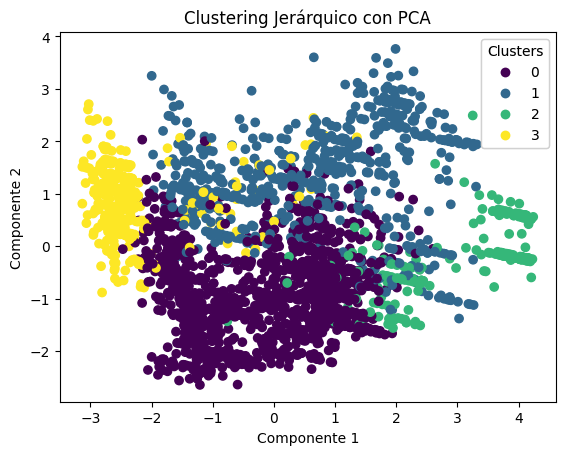

In [143]:
jer = AgglomerativeClustering(n_clusters=4)
clusters_jer = jer.fit_predict(X_scaled)
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_jer, cmap='viridis')
plt.title("Clustering Jerárquico con PCA")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")

legend = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend)

plt.show()

DENDOGRAMA

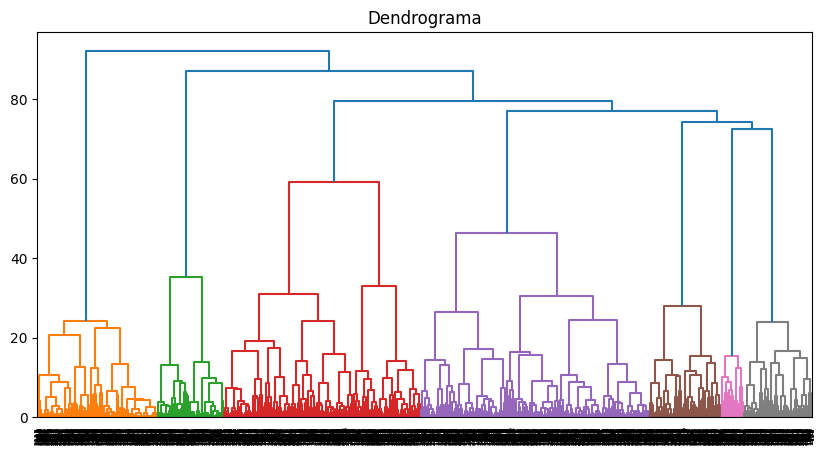

In [144]:
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(Z)
plt.title("Dendrograma")
plt.show()

RESUMEN COMPARACIÓN MÓDELOS

Se logró segmentar exitosamente a los clientes utilizando técnicas de aprendizaje no supervisado. K-Means presentó el mejor desempeño en términos de interpretabilidad y separación de grupos. Estos segmentos permiten diseñar estrategias de marketing más efectivas, aumentando la retención y el valor del cliente.

Se visualizaron los resultados de los algoritmos DBSCAN y agrupamiento jerárquico mediante técnicas de reducción dimensional (PCA y t-SNE), permitiendo comparar la forma y separación de los clusters obtenidos.

| Método     | Ventajas                            | Desventajas           |
| ---------- | ----------------------------------- | --------------------- |
| K-Means    | Simple, rápido, interpretable       | Necesita K            |
| DBSCAN     | Detecta ruido, flexible             | Sensible a parámetros |
| Jerárquico | Visual (dendrograma), no requiere K | Más lento             |


En conclusión: Considero que después de realziar  el método del codo y coeficiente de silueta debería haber escogido 3 clústeres y no 4. Queda como aprendizaje primero hacer estos análisis y luego definir clusters y sacar insights de los grupos encontrados.
Por otro lado, el método elegido fue PCA con cluster k=4 ya que ahí se pudieron definir y caracterizar bien los grupos encontrados.